In [1]:
import os
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Paths
csv_path = "Data_Entry_2017_v2020.csv"
img_dir = "images"

# Load CSV
df = pd.read_csv(csv_path)

# Filter only images that exist in your current folder
available_imgs = set(os.listdir(img_dir))
df = df[df['Image Index'].isin(available_imgs)]

In [2]:
from scipy.stats import mode

# Step 1: Define target labels
target_labels = ['No Finding', 'Pneumothorax', 'Cardiomegaly', 'Mass', 'Nodule']

def is_valid_entry(label_str):
    return any(lbl in label_str.split('|') for lbl in target_labels)

def extract_multiclass_label(label_str):
    labels = label_str.split('|')
    for i, disease in enumerate(target_labels):
        if disease in labels:
            return i
    return len(target_labels) - 1  # No Finding

df = df[df['Finding Labels'].apply(is_valid_entry)]
df['label'] = df['Finding Labels'].apply(extract_multiclass_label)

def most_common_label(x):
    counts = x.value_counts()
    if len(counts) == 0:
        return x.iloc[0]  # fallback (should rarely happen)
    return counts.idxmax()  # picks first in case of tie

patient_df = df.groupby('Patient ID')['label'].agg(most_common_label).reset_index()

# Step 4: Stratified split by patient label
train_patients, val_patients = train_test_split(
    patient_df,
    test_size=0.2,
    stratify=patient_df['label'],
    random_state=42
)

# Step 5: Split original DataFrame
train_df = df[df['Patient ID'].isin(train_patients['Patient ID'])]
val_df = df[df['Patient ID'].isin(val_patients['Patient ID'])]

In [3]:
from torch.utils.data import WeightedRandomSampler

# Count how often each class appears in the training set
label_counts = np.zeros(len(target_labels))
for labels in train_df['Finding Labels']:
    for i, disease in enumerate(target_labels):
        if disease in labels.split('|'):
            label_counts[i] += 1

# Inverse frequency = rarer class gets higher weight
class_weights = 1.0 / label_counts
print("Class weights (inverse frequency):", class_weights)

# Assign a sampling weight to each training sample
sample_weights = []
for labels in train_df['Finding Labels']:
    weight = 0.0
    for i, disease in enumerate(target_labels):
        if disease in labels.split('|'):
            weight += class_weights[i]
    sample_weights.append(weight)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class weights (inverse frequency): [4.91424640e-05 7.18390805e-04 1.01214575e-03 6.91085003e-04
 5.53709856e-04]


In [4]:
# Print summary
print(f"Train images: {len(train_df)}, Val images: {len(val_df)}")
print(f"Train patients: {len(train_patients)}, Val patients: {len(val_patients)}\n")

print("Train class distribution:")
print(train_df['label'].value_counts())

print("\nValidation class distribution:")
print(val_df['label'].value_counts())

Train images: 25586, Val images: 6905
Train patients: 8432, Val patients: 2108

Train class distribution:
label
0    20349
4     1532
1     1392
3     1342
2      971
Name: count, dtype: int64

Validation class distribution:
label
0    5473
1     487
4     364
3     363
2     218
Name: count, dtype: int64


In [5]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, target_labels=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.target_labels = target_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)

        labels = self.df.loc[idx, 'Finding Labels'].split('|')
        target = torch.zeros(len(self.target_labels), dtype=torch.float32)
        for i, disease in enumerate(self.target_labels):
            if disease in labels:
                target[i] = 1.0

        return image, target

In [6]:
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# No augmentation for validation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = ChestXrayDataset(train_df, img_dir, train_transform, target_labels)
val_dataset = ChestXrayDataset(val_df, img_dir, val_transform, target_labels)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

In [7]:
from collections import Counter
import torch

label_counter = Counter()
n_batches = 16  # check more batches if you like

for i, (images, targets) in enumerate(train_loader):
    if i >= n_batches:
        break
    for t in targets:
        for idx, val in enumerate(t):
            if val == 1:
                label_counter[idx] += 1

print("\nSampled label distribution (approximate, from batches):")
for i, label in enumerate(target_labels):
    print(f"{label:15}: {label_counter[i]}")


Sampled label distribution (approximate, from batches):
No Finding     : 47
Pneumothorax   : 49
Cardiomegaly   : 51
Mass           : 75
Nodule         : 64


In [8]:
def train_one_epoch(loader, model, optimizer, criterion, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in tqdm(loader, desc=f"Epoch {epoch+1} [Train]", leave=False):
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # shape: [B, num_classes]
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.sigmoid(outputs) > 0.5  # threshold logits for multi-label
        correct += (preds == targets.bool()).sum().item()
        total += targets.numel()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    print(f"Epoch {epoch+1} - Train Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc*100:.2f}%")

    return epoch_loss, epoch_acc


In [9]:
def evaluate(loader, model, criterion, device, epoch):
    model.eval()
    running_loss = 0
    all_outputs = []
    all_targets = []

    with torch.no_grad():
        for images, targets in tqdm(loader, desc=f"Epoch {epoch+1} [Val]", leave=False):
            images, targets = images.to(device), targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)
            running_loss += loss.item()

            all_outputs.append(torch.sigmoid(outputs).cpu())
            all_targets.append(targets.cpu())

    all_outputs = torch.cat(all_outputs)
    all_targets = torch.cat(all_targets)

    preds = (all_outputs > 0.5).int()
    targets = all_targets.int()

    correct = (preds == targets).sum().item()
    total = targets.numel()
    accuracy = correct / total
    avg_loss = running_loss / len(loader)

    print(f"Epoch {epoch+1} - Val Loss: {avg_loss:.4f} | Accuracy: {accuracy*100:.2f}%")

    return avg_loss, accuracy

In [10]:
from torchvision.models import googlenet, GoogLeNet_Weights
import torch.nn as nn

def get_modified_googlenet(num_classes):
    weights = GoogLeNet_Weights.DEFAULT
    model = googlenet(weights=weights, transform_input=False)

    # First conv for grayscale
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Final layer for multi-label output
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


In [11]:
from torch.optim.lr_scheduler import StepLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_modified_googlenet(num_classes=len(target_labels)).to(device)

# Compute pos_weight for each class
total_samples = len(train_df)
pos_counts = np.zeros(len(target_labels), dtype=np.float32)

for label_str in train_df['Finding Labels']:
    labels_present = [int(label in label_str.split('|')) for label in target_labels]
    pos_counts += np.array(labels_present)

neg_counts = total_samples - pos_counts
# Add small epsilon to avoid division by zero
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-5), dtype=torch.float32).to(device)

print("Pos weights per class:", pos_weight.cpu().numpy())

# Loss, optimizer, scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

num_epochs = 10
best_acc = 0
patience = 5
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(train_loader, model, optimizer, criterion, device, epoch)
    val_loss, val_acc = evaluate(val_loader, model, criterion, device, epoch)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step()
    print(f"Learning Rate after Epoch {epoch+1}: {scheduler.get_last_lr()[0]:.5f}")

    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

model.load_state_dict(torch.load("best_model.pt"))

Pos weights per class: [ 0.2573591 17.380747  24.89676   16.6821    13.16722  ]


Epoch 1 - Train Loss: 1.4353 | Accuracy: 45.39%


Epoch 1 - Val Loss: 1.3227 | Accuracy: 29.22%
Learning Rate after Epoch 1: 0.00010


Epoch 2 - Train Loss: 1.2048 | Accuracy: 56.26%


Epoch 2 - Val Loss: 1.2898 | Accuracy: 33.71%
Learning Rate after Epoch 2: 0.00010


...

Epoch 9 - Train Loss: 0.4526 | Accuracy: 84.71%


Epoch 9 - Val Loss: 1.4127 | Accuracy: 58.96%
Learning Rate after Epoch 9: 0.00001


Epoch 10 - Train Loss: 0.4051 | Accuracy: 86.29%


Epoch 10 - Val Loss: 1.4886 | Accuracy: 60.41%
Learning Rate after Epoch 10: 0.00001


<All keys matched successfully>

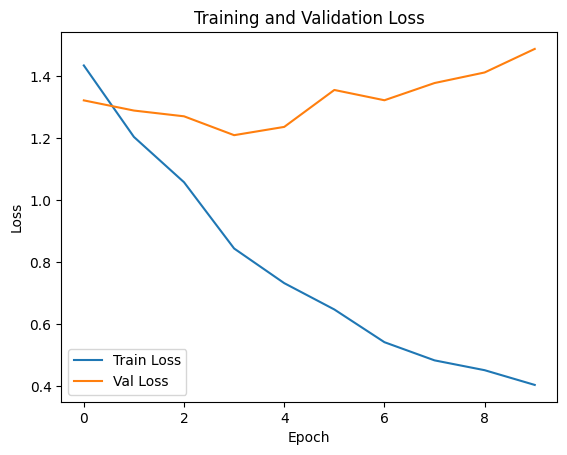

In [12]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [29]:
from sklearn.metrics import (
    precision_recall_curve,
    classification_report,
    multilabel_confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import torch

def evaluate_with_threshold_tuning(model, val_loader, target_labels, device):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_targets.append(targets.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    print("Collected probs and targets:")
    print("all_probs shape:", all_probs.shape)
    print("all_targets shape:", all_targets.shape)

    # Step 2: Compute optimal F1 threshold per class
    optimal_thresholds = []
    for i, label in enumerate(target_labels):
        precision, recall, thresholds = precision_recall_curve(all_targets[:, i], all_probs[:, i])
        f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
        best_idx = np.argmax(f1_scores)
        best_thresh = thresholds[best_idx]
        optimal_thresholds.append(best_thresh)

        # Plot F1 vs threshold (optional)
        plt.figure(figsize=(6, 4))
        plt.plot(thresholds, f1_scores[:-1], label="F1-score")
        plt.axvline(best_thresh, color='r', linestyle='--', label=f"Best: {best_thresh:.2f}")
        plt.title(f"F1-Score vs Threshold - {label}")
        plt.xlabel("Threshold")
        plt.ylabel("F1 Score")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

        print(f"{label:15s} | Best threshold: {best_thresh:.3f} | Best F1: {f1_scores[best_idx]:.4f}")

    optimal_thresholds = np.array(optimal_thresholds)

    # Step 3: Apply thresholds
    final_preds = np.zeros_like(all_probs)
    for i in range(all_probs.shape[1]):
        final_preds[:, i] = (all_probs[:, i] > optimal_thresholds[i]).astype(int)

    # Step 4: Classification Report
    print("\nClassification Report (F1-Optimized Thresholds):")
    print(classification_report(
        all_targets,
        final_preds,
        target_names=target_labels,
        digits=4,
        zero_division=0
    ))

    # Step 5: Confusion Matrices
    conf_matrices = multilabel_confusion_matrix(all_targets, final_preds)
    for i, label in enumerate(target_labels):
        cm = conf_matrices[i].astype(np.float32)
        cm_sum = cm.sum()
        cm_percent = (cm / cm_sum * 100) if cm_sum > 0 else cm

        fig, ax = plt.subplots(figsize=(4, 4))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm_percent,
            display_labels=["No", "Yes"]
        )
        disp.plot(cmap="Blues", values_format=".1f", ax=ax)
        ax.set_title(f"{label} (Normalized %)")
        plt.tight_layout()
        plt.show()

    return final_preds, all_targets, optimal_thresholds


Collected probs and targets:
all_probs shape: (6905, 5)
all_targets shape: (6905, 5)


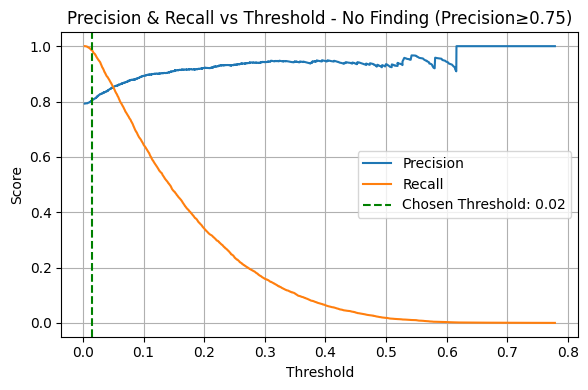

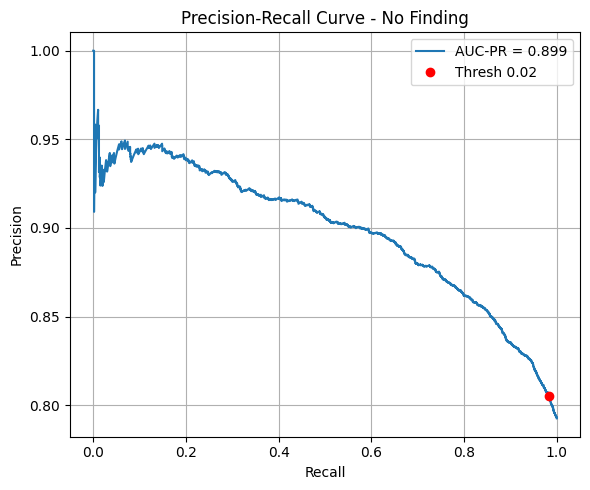

No Finding      | Threshold: 0.016 | F1: 0.886 | Precision: 0.805 | Recall: 0.984


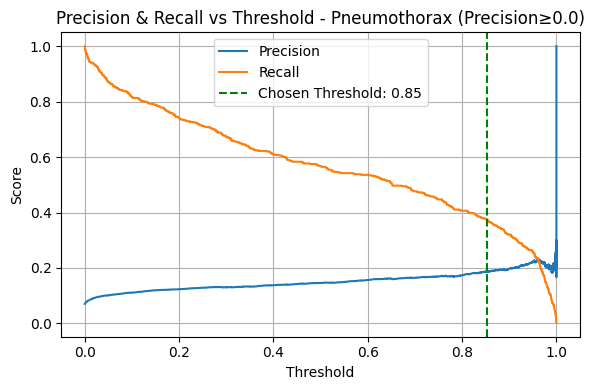

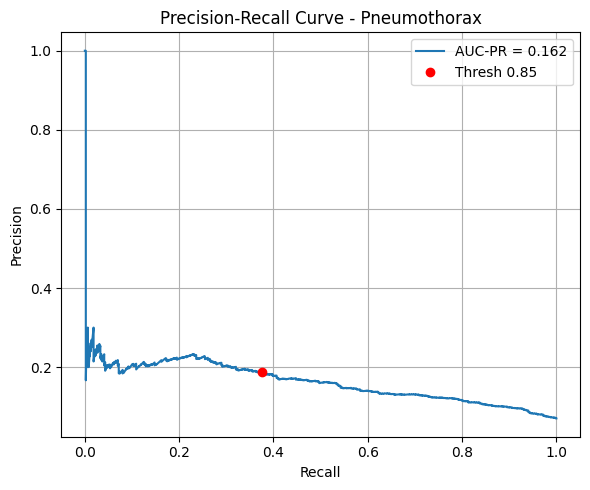

Pneumothorax    | Threshold: 0.852 | F1: 0.251 | Precision: 0.188 | Recall: 0.376


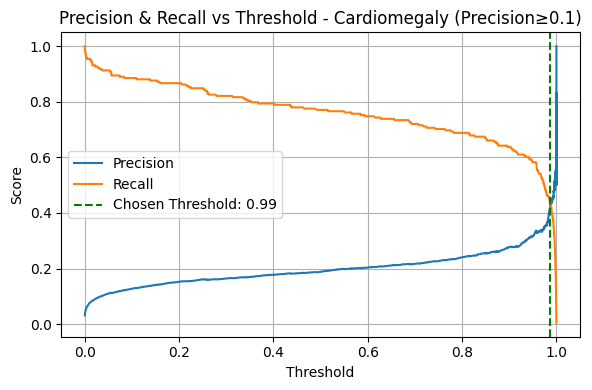

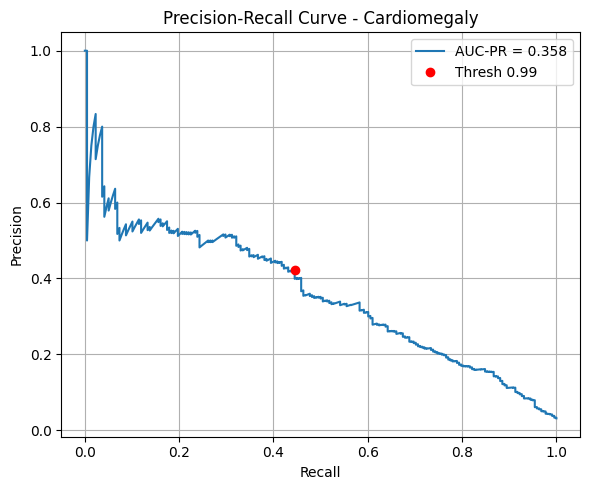

Cardiomegaly    | Threshold: 0.987 | F1: 0.434 | Precision: 0.424 | Recall: 0.445


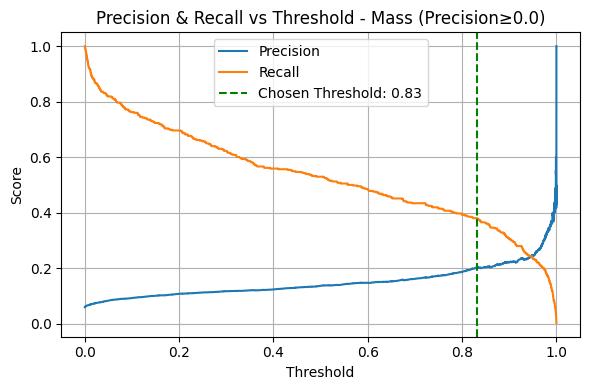

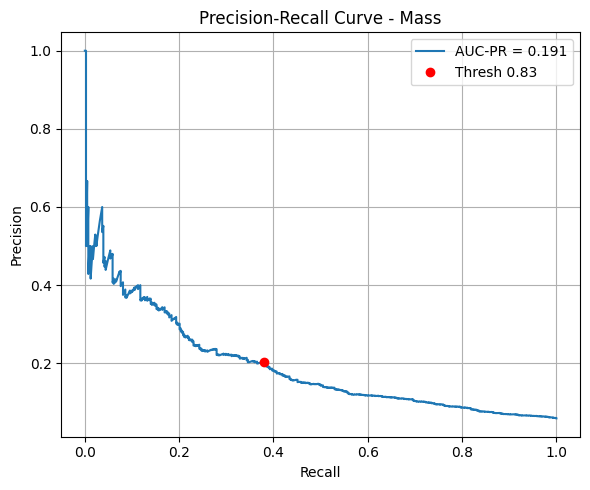

Mass            | Threshold: 0.832 | F1: 0.264 | Precision: 0.203 | Recall: 0.380


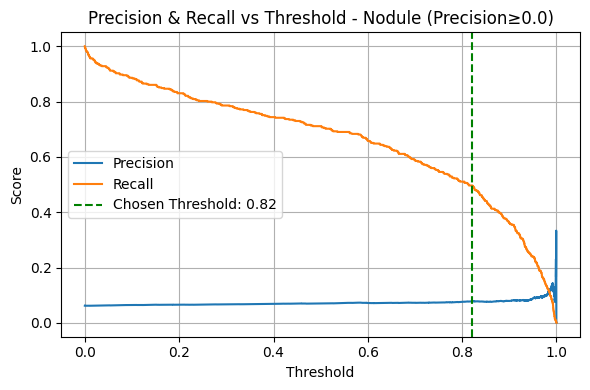

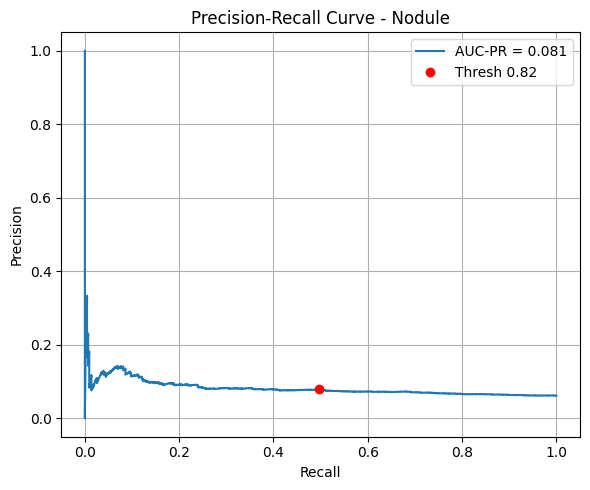

Nodule          | Threshold: 0.822 | F1: 0.135 | Precision: 0.078 | Recall: 0.497

Classification Report (Thresholds tuned with precision constraints):
              precision    recall  f1-score   support

  No Finding     0.8053    0.9837    0.8856      5473
Pneumothorax     0.1874    0.3737    0.2497       487
Cardiomegaly     0.4211    0.4404    0.4305       218
        Mass     0.2016    0.3775    0.2628       408
      Nodule     0.0781    0.4942    0.1349       429

   micro avg     0.5305    0.8593    0.6560      7015
   macro avg     0.3387    0.5339    0.3927      7015
weighted avg     0.6709    0.8593    0.7452      7015
 samples avg     0.5941    0.8673    0.6829      7015



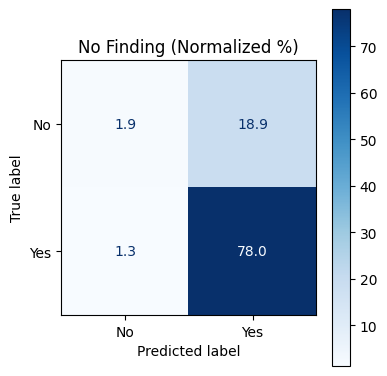

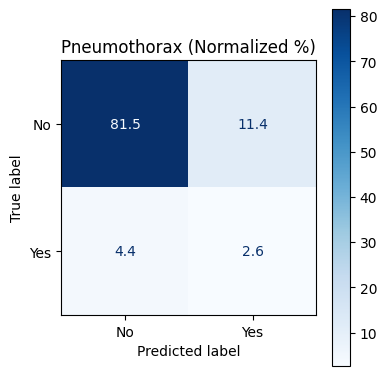

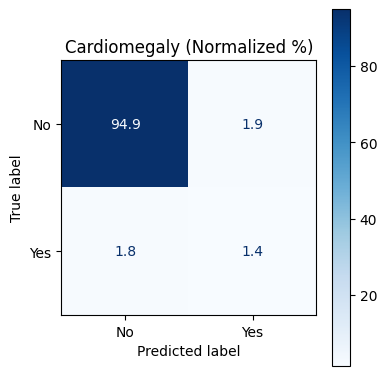

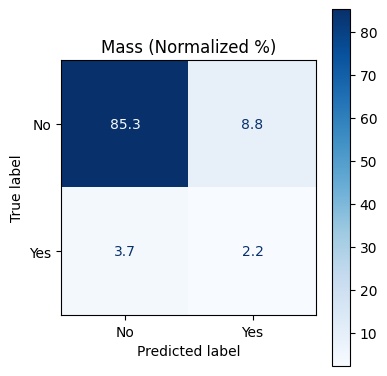

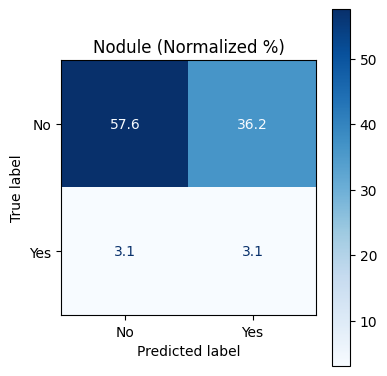

In [30]:
final_preds, all_targets, optimal_thresholds = evaluate_with_precision_thresholds(
    model=model,
    val_loader=val_loader,
    target_labels=target_labels,
    device=device
)